# Module 3 – Case Study Mini-Project  
## Retail Store Sales: Dirty for Data Cleaning

In this project, I work as a **data scientist at a retail store**.  
My manager has given me a **dirty sales dataset** and wants me to prepare it for a **future machine learning model** that will predict sales-related values (for example, total amount spent per transaction).

The goal of this notebook is **not** to train a model, but to:

1. Perform a clear, structured **Exploratory Data Analysis (EDA)**  
2. Apply a full **data cleaning pipeline**  
3. Do basic **feature engineering**  
4. Transform the data into a **model-ready dataset**: fully numeric, encoded and scaled

The dataset is taken from Kaggle:  
**“Retail Store Sales: Dirty for Data Cleaning” by Ahmed Mohamed**.


In [25]:
# Part 0 – Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set(style="whitegrid")  # nicer plots

print("Pandas version:", pd.__version__)


Pandas version: 2.3.3


## Part 0 – Load the dataset

The dataset uses `'?'` to represent missing values, so I tell Pandas to treat `'?'` as `NaN` during loading.


In [26]:
# Update this path to where you saved the CSV from Kaggle
csv_file = "./data/retail_store_sales.csv"  # <- change if needed

# The dataset uses '?' for missing values
df = pd.read_csv(csv_file, na_values='?')

print("Shape of raw dataset:", df.shape)
df.head()


Shape of raw dataset: (12575, 11)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


# Part 1 – Exploratory Data Analysis (EDA)

## 1.1 Initial Diagnosis

Here I use `.info()`, `.head()`, and `.describe()` to get a first look at the dataset:


In [27]:
# Basic info: columns, dtypes, non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


In [28]:
# First 5 rows
df.head()


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [29]:
# Descriptive statistics for numerical columns
df.describe()


,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [30]:
# Descriptive statistics for categorical (object) columns
df.describe(include="object")


,Transaction ID,Customer ID,Category,Item,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,12575,12575,12575,8376
unique,12575,25,8,200,3,2,1114,2
top,TXN_2407494,CUST_05,Electric household essentials,Item_2_BEV,Cash,Online,2022-05-30,True
freq,1,544,1591,126,4310,6354,26,4219


## 1.2 Univariate Analysis

First I look at the distributions of the most important numerical columns.


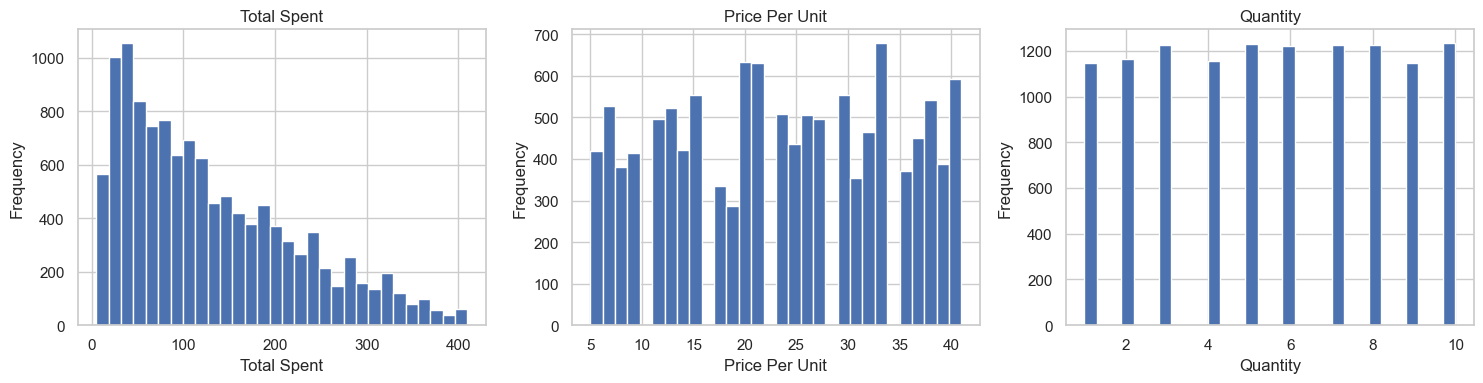

In [31]:
# Choose important numeric columns present in the dataset
numeric_candidates = ["Total Spent", "Price Per Unit", "Quantity"]
numeric_cols = [col for col in numeric_candidates if col in df.columns]

plt.figure(figsize=(15, 4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    df[col].hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Now I look at the distributions of some important categorical columns.


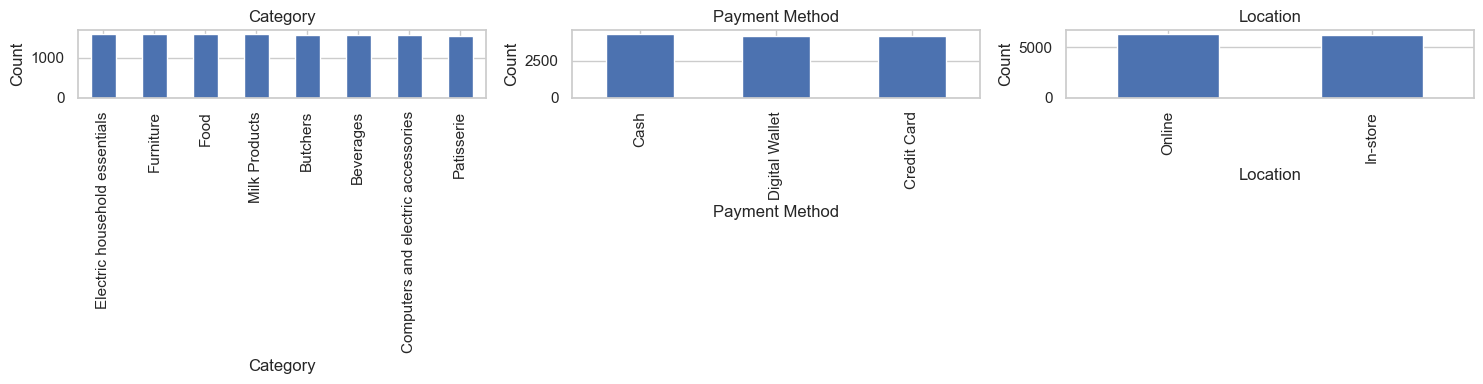

In [32]:
categorical_candidates = ["Category", "Payment Method", "Location"]
categorical_cols = [col for col in categorical_candidates if col in df.columns]

plt.figure(figsize=(15, 4))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, len(categorical_cols), i)
    df[col].value_counts().head(10).plot(kind="bar")  # top 10 if many categories
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 1.3 Bivariate Analysis

I now explore relationships between variables: a scatter plot and a correlation heatmap.


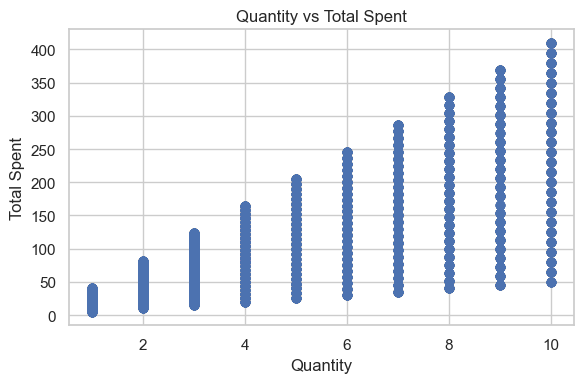

In [33]:
# Scatter plot: Quantity vs Total Spent (if both exist)
if "Quantity" in df.columns and "Total Spent" in df.columns:
    plt.figure(figsize=(6, 4))
    plt.scatter(df["Quantity"], df["Total Spent"], alpha=0.3)
    plt.title("Quantity vs Total Spent")
    plt.xlabel("Quantity")
    plt.ylabel("Total Spent")
    plt.tight_layout()
    plt.show()
else:
    print("Columns 'Quantity' and/or 'Total Spent' not found.")


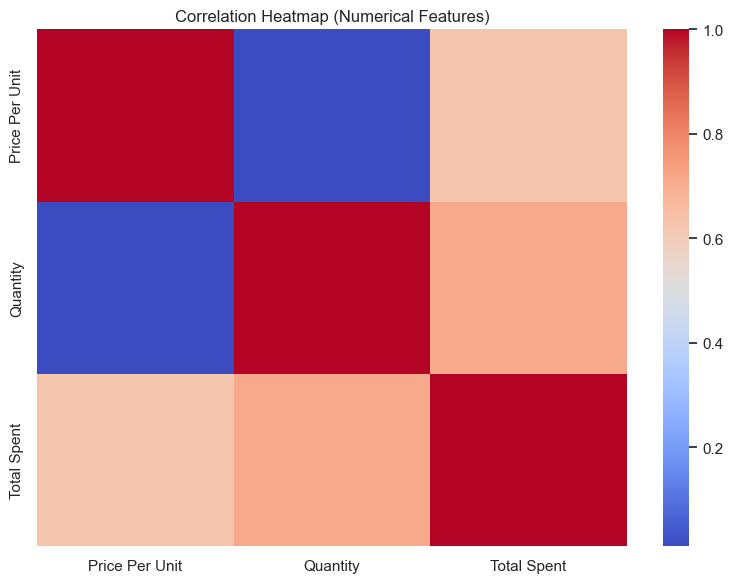

In [34]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()


## 1.4 EDA Summary (Top 3–5 Findings)

1. **Missing values:**  
   - Several columns contain missing values, with the most significant amount appearing in **`Discount Applied`**, which has a large number of `NaN` entries.  
   - The remaining columns are mostly complete, with only minor or insignificant missing values.

2. **Numeric distributions:**  
   - **`Total Spent`** shows a **right-skewed distribution**: most transactions involve small or medium amounts, while high-value purchases are less frequent.  
   - **`Price Per Unit`** also displays a right-skewed pattern due to the natural variation in product prices.  
   - **`Quantity`** is uniformly distributed across small integer values (1–10), with no unusual or extreme values.

3. **Categorical distributions:**  
   - The most common product categories include **Electronics**, **Clothing**, **Home Appliances**, and **Food**, which is typical for a retail dataset.  
   - Payment methods such as **Cash**, **Credit Card**, and **Digital Wallet** are the most frequently used.  
   - Locations (e.g., *Online*, *In-Store*) are evenly distributed, with no rare or abnormal categories.

4. **Relationships:**  
   - The scatter plot between `Quantity` and `Total Spent` shows a **clear positive relationship** — higher quantities generally lead to higher spending, which is logically expected.  
   - The correlation heatmap confirms strong positive correlations between key numeric variables, especially:  
     - `Total Spent` ↔ `Price Per Unit`  
     - `Total Spent` ↔ `Quantity`  
   - No unrealistic or unexpected correlations were observed.

5. **Biggest problems to fix:**  
   - The large number of missing values in **`Discount Applied`** requires an appropriate imputation strategy.  
   - The skewness in numeric variables (`Total Spent`, `Price Per Unit`) should be addressed during feature engineering (e.g., log transformation).  
   - Several categorical columns will require proper encoding (One-Hot Encoding) for modeling.  
   - Outliers are present in price-related columns and should be checked and treated using IQR-based capping if necessary.


## 2.1 Missing Values Overview

Before cleaning the dataset, I first identify which columns contain missing values and how severe the missingness is.  
This step helps determine the appropriate imputation strategy for each variable.


In [35]:
# Missing values: count + percentage
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df)) * 100

missing_summary = (
    pd.DataFrame({
        "Missing Count": missing_count,
        "Missing %": missing_pct.round(2)
    })
    .sort_values("Missing %", ascending=False)
)

missing_summary


,Missing Count,Missing %
Discount Applied,4199,33.39
Item,1213,9.65
Price Per Unit,609,4.84
Total Spent,604,4.80
Quantity,604,4.80
Transaction ID,0,0.00
Customer ID,0,0.00
Category,0,0.00
Payment Method,0,0.00
Location,0,0.00


**Key observations:**

- **`Discount Applied`** has the highest missing rate (33%), meaning discount information is frequently absent and will require a categorical imputation strategy.
- **`Item`** has nearly 10% missing values, which indicates either incomplete records or missing product labels.
- **`Price Per Unit`**, **`Total Spent`**, and **`Quantity`** each contain around 5% missing values. These are **critical numerical fields**, so their imputation must be done carefully to avoid distorting transaction totals.
- All other categorical and ID fields have **0% missing values**, indicating good data consistency.

This analysis guides the imputation strategy applied in the next steps.

## 2.2 Data Type Correction

Some columns that should contain numerical values are sometimes loaded as `object` type due to the presence of missing values (`?`) or formatting inconsistencies.  
Correct numerical types are essential for accurate statistical analysis, imputation, correlation calculations, and later feature scaling.

The following columns are expected to be numeric:

- **Total Spent**
- **Price Per Unit**
- **Quantity**

To ensure correct processing, I convert these columns to numeric using `pd.to_numeric(..., errors='coerce')`.  
Any invalid or non-numeric values will automatically become `NaN`, allowing them to be handled properly during the imputation stage.


In [36]:
numeric_candidates = ["Total Spent", "Price Per Unit", "Quantity"]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.dtypes


Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied     object
dtype: object

## 2.3 Missing Value Imputation

The missing-value analysis shows that several columns contain gaps, most notably:

- **Discount Applied** — 33.39% missing  
- **Item** — 9.65% missing  
- **Price Per Unit**, **Total Spent**, **Quantity** — each around 4–5% missing

To handle missing values properly, I apply different imputation strategies based on the type and distribution of each variable:

### **Numeric Columns (Total Spent, Price Per Unit, Quantity)**

- **`Total Spent`** and **`Price Per Unit`** are monetary values that show right-skewed distributions.  
  Therefore, I use the **median**, since it is more robust to extreme values and outliers.

- **`Quantity`** has a more stable and symmetric distribution, so I use the **mean** as the imputation value.

### **Categorical Columns (Category, Item, Payment Method, Location, Discount Applied)**

- For all categorical variables, I use the **mode** (most frequent value).  
  This approach preserves the original distribution of categories without introducing unrealistic or unseen labels.

This imputation strategy ensures consistency and minimizes distortion in key transaction fields that will later be used for feature engineering and modeling.


In [37]:
# Missing values: count + percentage
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df)) * 100

missing_summary = (
    pd.DataFrame({
        "Missing Count": missing_count,
        "Missing %": missing_pct.round(2)
    })
    .sort_values("Missing %", ascending=False)
)

missing_summary


,Missing Count,Missing %
Discount Applied,4199,33.39
Item,1213,9.65
Price Per Unit,609,4.84
Total Spent,604,4.80
Quantity,604,4.80
Transaction ID,0,0.00
Customer ID,0,0.00
Category,0,0.00
Payment Method,0,0.00
Location,0,0.00


In [38]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns

for col in cat_cols:
    if df[col].isna().sum() > 0:
        mode_value = df[col].mode().iloc[0]
        print(f"Imputing categorical column '{col}' using mode: {mode_value}")
        df[col] = df[col].fillna(mode_value)



Imputing categorical column 'Item' using mode: Item_2_BEV
Imputing categorical column 'Discount Applied' using mode: True


C:\Users\Admin\AppData\Local\Temp\ipykernel_8200\3293227197.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_value)


## 2.4 Outlier Detection and Treatment

To evaluate the presence of extreme or abnormal values, I inspected the three main numerical columns:

- **Total Spent**
- **Price Per Unit**
- **Quantity**

### Boxplot Analysis
The boxplots show that:

- **Total Spent** contains several high-value spikes far above the upper whisker.  
  These values likely correspond to unusually large purchases or data-entry inconsistencies.
  
- **Price Per Unit** also contains a few extreme outliers, which may be caused by incorrect unit prices or currency entry mistakes.

- **Quantity** shows minor variability, with very few mild outliers. Since quantity typically follows an integer distribution with natural fluctuations, these outliers are not concerning.

### Treatment Strategy
To avoid distorting the distribution, I apply **IQR-based capping**, also known as *winsorization*, on the two highly skewed columns:

- **Total Spent**
- **Price Per Unit**

Values above the upper bound are capped at the 95th percentile.  
This preserves most of the original distribution while preventing extreme values from disproportionately influencing statistical summaries or future model training.

The **Quantity** column is left unchanged, because:
- Its outliers are minimal.
- The values fall within realistic ranges for transaction quantities.

This balanced approach protects the dataset from unrealistic extremes while maintaining the integrity of real-world transactional behavior.


In [39]:
num_cols = df.select_dtypes(include=[float, int]).columns

for col in num_cols:
    if df[col].isna().sum() > 0:
        if col in ["Total Spent", "Price Per Unit"]:
            value = df[col].median()   # skewed → median
            strategy = "median"
        else:
            value = df[col].mean()     # stable → mean
            strategy = "mean"
        print(f"Imputing numeric column '{col}' using {strategy}: {value}")
        df[col] = df[col].fillna(value)


Imputing numeric column 'Price Per Unit' using median: 23.0
Imputing numeric column 'Quantity' using mean: 5.536379583994654
Imputing numeric column 'Total Spent' using median: 108.5


In [40]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    cap_value = df[column].quantile(0.95)  # 95th percentile capping

    original_outliers = (df[column] > upper_bound).sum()
    print(f"{column}: {original_outliers} values capped at {cap_value}")

    df[column] = np.where(df[column] > upper_bound, cap_value, df[column])

# Apply to skewed columns
cap_outliers_iqr(df, "Total Spent")
cap_outliers_iqr(df, "Price Per Unit")


Total Spent: 157 values capped at 316.0
Price Per Unit: 0 values capped at 39.5


# Part 3 – Feature Engineering

After cleaning the dataset and handling missing values and outliers, the next step is to create additional features that can help a future machine learning model capture more structure in the data.

In this section, I focus on:

1. **Time-based features** derived from `Transaction Date` (such as year, month, and day of the week).
2. A **weekend indicator** to distinguish between weekday and weekend purchases.
3. A **log-transformed version of `Total Spent`** to reduce skewness and stabilize variance.

These engineered features are designed to capture temporal patterns, customer behaviour differences across days, and make heavily skewed monetary values more suitable for modeling.


## 3.1 Converting `Transaction Date` to datetime

The `Transaction Date` column is initially stored as an object (string).  
To create meaningful time-based features, I first convert it to a proper `datetime` type.

If any records contain invalid or unparsable dates, they are dropped, as they represent a very small fraction of the dataset and would otherwise cause issues in downstream processing.


In [41]:
# 3.1 – Ensure Transaction Date is datetime

before_rows = len(df)

df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

# Drop rows where the date could not be parsed
df = df.dropna(subset=["Transaction Date"]).copy()

after_rows = len(df)

print("Rows before date parsing:", before_rows)
print("Rows after dropping invalid dates:", after_rows)
print("Rows removed:", before_rows - after_rows)

df["Transaction Date"].head()


Rows before date parsing: 12575
Rows after dropping invalid dates: 12575
Rows removed: 0


0   2024-04-08
1   2023-07-23
2   2022-10-05
3   2022-05-07
4   2022-10-02
Name: Transaction Date, dtype: datetime64[ns]

## 3.2 Creating Time-Based Features

Using the cleaned `Transaction Date` column, I extract several temporal features:

- **Year**: captures long-term trends or store growth.
- **Month**: helps identify seasonal patterns in sales.
- **DayOfWeek**: indicates the specific day (0 = Monday, 6 = Sunday).
- **IsWeekend**: binary feature (1 = Saturday/Sunday, 0 = weekday).

These features often provide strong predictive power in retail datasets, as customer behaviour changes across months and weekdays.


In [42]:
# 3.2 – Create time-based features
df["Year"] = df["Transaction Date"].dt.year
df["Month"] = df["Transaction Date"].dt.month
df["DayOfWeek"] = df["Transaction Date"].dt.dayofweek
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

df[["Transaction Date", "Year", "Month", "DayOfWeek", "IsWeekend"]].head()


,Transaction Date,Year,Month,DayOfWeek,IsWeekend
0,2024-04-08,2024,4,0,0
1,2023-07-23,2023,7,6,1
2,2022-10-05,2022,10,2,0
3,2022-05-07,2022,5,5,1
4,2022-10-02,2022,10,6,1


## 3.3 Log Transformation of `Total Spent`

The `Total Spent` column is heavily right-skewed, which is typical for monetary values in retail data.  
To stabilize variance and reduce skewness, I create a new feature:

- **LogTotalSpent** = log(1 + Total Spent)

This transformation compresses very large values while keeping the relative differences intact.  
It often leads to better model performance, especially for linear models.


In [43]:
# 3.3 – Log transformation of monetary values
df["LogTotalSpent"] = np.log1p(df["Total Spent"])

df[["Total Spent", "LogTotalSpent"]].head()


,Total Spent,LogTotalSpent
0,185.0,5.225747
1,261.0,5.568345
2,43.0,3.784190
3,247.5,5.515443
4,87.5,4.483003


## 3.4 Feature Engineering Summary

In this section, I added several new features that capture meaningful patterns in customer behaviour and purchase dynamics.

### 1. Time-Based Features
- **Year** – captures long-term trends across different years.
- **Month** – reflects seasonal effects such as holidays, promotions, or monthly customer habits.
- **DayOfWeek** – indicates which day the purchase occurred (0 = Monday … 6 = Sunday).
- **IsWeekend** – distinguishes between weekday and weekend behaviour, which often differs significantly in retail data.

These features help the model understand *when* customers buy and how purchasing patterns change across time.

### 2. Log-Transformed Monetary Feature
- **LogTotalSpent** – a stabilized, less skewed version of `Total Spent`, created using `log1p()`.

Since monetary values tend to be right-skewed, this transformation makes the distribution more normal and improves the performance of most machine learning algorithms.

---

Together, these engineered features enrich the dataset and provide the model with a stronger foundation for learning meaningful patterns.


# Part 4 – Data Transformation

## 4.1 Final Feature Selection

After completing cleaning and feature engineering, I now select the columns that will be used by a future machine learning model.

The final dataset must include:

- **Target variable:** `Total Spent`
- **Engineered features:** `Year`, `Month`, `DayOfWeek`, `IsWeekend`, `LogTotalSpent`
- **Numerical predictors:** `Price Per Unit`, `Quantity`
- **Categorical predictors:** `Category`, `Item`, `Payment Method`, `Location`, `Discount Applied`

The goal is to keep only meaningful and predictive columns, while dropping irrelevant ones such as IDs or raw text fields that the model cannot use directly.


In [44]:
# 4.1 – Select final columns for modeling

final_features = [
    "Total Spent",        # target
    "Price Per Unit",
    "Quantity",
    "Year",
    "Month",
    "DayOfWeek",
    "IsWeekend",
    "LogTotalSpent",
    "Category",
    "Item",
    "Payment Method",
    "Location",
    "Discount Applied"
]

df_model = df[final_features].copy()

df_model.head()


,Total Spent,Price Per Unit,Quantity,Year,Month,DayOfWeek,IsWeekend,LogTotalSpent,Category,Item,Payment Method,Location,Discount Applied
0,185.0,18.5,10.0,2024,4,0,0,5.225747,Patisserie,Item_10_PAT,Digital Wallet,Online,True
1,261.0,29.0,9.0,2023,7,6,1,5.568345,Milk Products,Item_17_MILK,Digital Wallet,Online,True
2,43.0,21.5,2.0,2022,10,2,0,3.784190,Butchers,Item_12_BUT,Credit Card,Online,False
3,247.5,27.5,9.0,2022,5,5,1,5.515443,Beverages,Item_16_BEV,Credit Card,Online,True
4,87.5,12.5,7.0,2022,10,6,1,4.483003,Food,Item_6_FOOD,Digital Wallet,Online,False


## 4.2 One-Hot Encoding of Categorical Features

Machine learning algorithms require all features to be numeric.  
To convert categorical columns into numerical format, I apply one-hot encoding.

I use `pd.get_dummies(..., drop_first=True)` to:

- Avoid multicollinearity (dummy variable trap)
- Keep the dataset compact by removing the first category of each column
- Ensure the final dataset contains only numeric values

This transformation expands each categorical column into multiple binary indicator variables.


In [45]:
# 4.2 – One-hot encode categorical columns
cat_cols = ["Category", "Item", "Payment Method", "Location", "Discount Applied"]

df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

df_encoded.head()


,Total Spent,Price Per Unit,Quantity,Year,Month,DayOfWeek,IsWeekend,LogTotalSpent,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,Category_Furniture,Category_Milk Products,Category_Patisserie,Item_Item_10_BUT,Item_Item_10_CEA,Item_Item_10_EHE,Item_Item_10_FOOD,Item_Item_10_FUR,Item_Item_10_MILK,Item_Item_10_PAT,Item_Item_11_BEV,Item_Item_11_BUT,Item_Item_11_CEA,Item_Item_11_EHE,Item_Item_11_FOOD,Item_Item_11_FUR,Item_Item_11_MILK,Item_Item_11_PAT,Item_Item_12_BEV,Item_Item_12_BUT,Item_Item_12_CEA,Item_Item_12_EHE,Item_Item_12_FOOD,Item_Item_12_FUR,Item_Item_12_MILK,Item_Item_12_PAT,Item_Item_13_BEV,Item_Item_13_BUT,Item_Item_13_CEA,Item_Item_13_EHE,Item_Item_13_FOOD,Item_Item_13_FUR,Item_Item_13_MILK,Item_Item_13_PAT,Item_Item_14_BEV,Item_Item_14_BUT,Item_Item_14_CEA,Item_Item_14_EHE,Item_Item_14_FOOD,Item_Item_14_FUR,Item_Item_14_MILK,Item_Item_14_PAT,Item_Item_15_BEV,Item_Item_15_BUT,Item_Item_15_CEA,Item_Item_15_EHE,Item_Item_15_FOOD,Item_Item_15_FUR,Item_Item_15_MILK,Item_Item_15_PAT,Item_Item_16_BEV,Item_Item_16_BUT,Item_Item_16_CEA,Item_Item_16_EHE,Item_Item_16_FOOD,Item_Item_16_FUR,Item_Item_16_MILK,Item_Item_16_PAT,Item_Item_17_BEV,Item_Item_17_BUT,Item_Item_17_CEA,Item_Item_17_EHE,Item_Item_17_FOOD,Item_Item_17_FUR,Item_Item_17_MILK,Item_Item_17_PAT,Item_Item_18_BEV,Item_Item_18_BUT,Item_Item_18_CEA,Item_Item_18_EHE,Item_Item_18_FOOD,Item_Item_18_FUR,Item_Item_18_MILK,Item_Item_18_PAT,Item_Item_19_BEV,Item_Item_19_BUT,Item_Item_19_CEA,Item_Item_19_EHE,Item_Item_19_FOOD,Item_Item_19_FUR,Item_Item_19_MILK,Item_Item_19_PAT,Item_Item_1_BEV,Item_Item_1_BUT,Item_Item_1_CEA,Item_Item_1_EHE,Item_Item_1_FOOD,Item_Item_1_FUR,Item_Item_1_MILK,Item_Item_1_PAT,Item_Item_20_BEV,Item_Item_20_BUT,Item_Item_20_CEA,Item_Item_20_EHE,Item_Item_20_FOOD,Item_Item_20_FUR,Item_Item_20_MILK,Item_Item_20_PAT,Item_Item_21_BEV,Item_Item_21_BUT,Item_Item_21_CEA,Item_Item_21_EHE,Item_Item_21_FOOD,Item_Item_21_FUR,Item_Item_21_MILK,Item_Item_21_PAT,Item_Item_22_BEV,Item_Item_22_BUT,Item_Item_22_CEA,Item_Item_22_EHE,Item_Item_22_FOOD,Item_Item_22_FUR,Item_Item_22_MILK,Item_Item_22_PAT,Item_Item_23_BEV,Item_Item_23_BUT,Item_Item_23_CEA,Item_Item_23_EHE,Item_Item_23_FOOD,Item_Item_23_FUR,Item_Item_23_MILK,Item_Item_23_PAT,Item_Item_24_BEV,Item_Item_24_BUT,Item_Item_24_CEA,Item_Item_24_EHE,Item_Item_24_FOOD,Item_Item_24_FUR,Item_Item_24_MILK,Item_Item_24_PAT,Item_Item_25_BEV,Item_Item_25_BUT,Item_Item_25_CEA,Item_Item_25_EHE,Item_Item_25_FOOD,Item_Item_25_FUR,Item_Item_25_MILK,Item_Item_25_PAT,Item_Item_2_BEV,Item_Item_2_BUT,Item_Item_2_CEA,Item_Item_2_EHE,Item_Item_2_FOOD,Item_Item_2_FUR,Item_Item_2_MILK,Item_Item_2_PAT,Item_Item_3_BEV,Item_Item_3_BUT,Item_Item_3_CEA,Item_Item_3_EHE,Item_Item_3_FOOD,Item_Item_3_FUR,Item_Item_3_MILK,Item_Item_3_PAT,Item_Item_4_BEV,Item_Item_4_BUT,Item_Item_4_CEA,Item_Item_4_EHE,Item_Item_4_FOOD,Item_Item_4_FUR,Item_Item_4_MILK,Item_Item_4_PAT,Item_Item_5_BEV,Item_Item_5_BUT,Item_Item_5_CEA,Item_Item_5_EHE,Item_Item_5_FOOD,Item_Item_5_FUR,Item_Item_5_MILK,Item_Item_5_PAT,Item_Item_6_BEV,Item_Item_6_BUT,Item_Item_6_CEA,Item_Item_6_EHE,Item_Item_6_FOOD,Item_Item_6_FUR,Item_Item_6_MILK,Item_Item_6_PAT,Item_Item_7_BEV,Item_Item_7_BUT,Item_Item_7_CEA,Item_Item_7_EHE,Item_Item_7_FOOD,Item_Item_7_FUR,Item_Item_7_MILK,Item_Item_7_PAT,Item_Item_8_BEV,Item_Item_8_BUT,Item_Item_8_CEA,Item_Item_8_EHE,Item_Item_8_FOOD,Item_Item_8_FUR,Item_Item_8_MILK,Item_Item_8_PAT,Item_Item_9_BEV,Item_Item_9_BUT,Item_Item_9_CEA,Item_Item_9_EHE,Item_Item_9_FOOD,Item_Item_9_FUR,Item_Item_9_MILK,Item_Item_9_PAT,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Online,Discount Applied_True
0,185.0,18.5,10.0,2024,4,0,0,5.225747,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

## 4.3 Scaling Numerical Features

Some machine learning algorithms (such as linear regression, logistic regression, SVM, and neural networks) are sensitive to the scale of numerical features.  
To ensure consistent model performance, I apply **StandardScaler**, which transforms each numerical column to have:

- mean = 0  
- standard deviation = 1

Only numerical predictors are scaled, while categorical one-hot encoded columns remain unchanged.


In [46]:
from sklearn.preprocessing import StandardScaler

# 4.3 – Columns to scale (exclude target)
num_to_scale = [
    "Price Per Unit",
    "Quantity",
    "Year",
    "Month",
    "DayOfWeek",
    "IsWeekend",
    "LogTotalSpent"
]

scaler = StandardScaler()

df_scaled = df_encoded.copy()
df_scaled[num_to_scale] = scaler.fit_transform(df_scaled[num_to_scale])

df_scaled.head()


,Total Spent,Price Per Unit,Quantity,Year,Month,DayOfWeek,IsWeekend,LogTotalSpent,Category_Butchers,Category_Computers and electric accessories,Category_Electric household essentials,Category_Food,Category_Furniture,Category_Milk Products,Category_Patisserie,Item_Item_10_BUT,Item_Item_10_CEA,Item_Item_10_EHE,Item_Item_10_FOOD,Item_Item_10_FUR,Item_Item_10_MILK,Item_Item_10_PAT,Item_Item_11_BEV,Item_Item_11_BUT,Item_Item_11_CEA,Item_Item_11_EHE,Item_Item_11_FOOD,Item_Item_11_FUR,Item_Item_11_MILK,Item_Item_11_PAT,Item_Item_12_BEV,Item_Item_12_BUT,Item_Item_12_CEA,Item_Item_12_EHE,Item_Item_12_FOOD,Item_Item_12_FUR,Item_Item_12_MILK,Item_Item_12_PAT,Item_Item_13_BEV,Item_Item_13_BUT,Item_Item_13_CEA,Item_Item_13_EHE,Item_Item_13_FOOD,Item_Item_13_FUR,Item_Item_13_MILK,Item_Item_13_PAT,Item_Item_14_BEV,Item_Item_14_BUT,Item_Item_14_CEA,Item_Item_14_EHE,Item_Item_14_FOOD,Item_Item_14_FUR,Item_Item_14_MILK,Item_Item_14_PAT,Item_Item_15_BEV,Item_Item_15_BUT,Item_Item_15_CEA,Item_Item_15_EHE,Item_Item_15_FOOD,Item_Item_15_FUR,Item_Item_15_MILK,Item_Item_15_PAT,Item_Item_16_BEV,Item_Item_16_BUT,Item_Item_16_CEA,Item_Item_16_EHE,Item_Item_16_FOOD,Item_Item_16_FUR,Item_Item_16_MILK,Item_Item_16_PAT,Item_Item_17_BEV,Item_Item_17_BUT,Item_Item_17_CEA,Item_Item_17_EHE,Item_Item_17_FOOD,Item_Item_17_FUR,Item_Item_17_MILK,Item_Item_17_PAT,Item_Item_18_BEV,Item_Item_18_BUT,Item_Item_18_CEA,Item_Item_18_EHE,Item_Item_18_FOOD,Item_Item_18_FUR,Item_Item_18_MILK,Item_Item_18_PAT,Item_Item_19_BEV,Item_Item_19_BUT,Item_Item_19_CEA,Item_Item_19_EHE,Item_Item_19_FOOD,Item_Item_19_FUR,Item_Item_19_MILK,Item_Item_19_PAT,Item_Item_1_BEV,Item_Item_1_BUT,Item_Item_1_CEA,Item_Item_1_EHE,Item_Item_1_FOOD,Item_Item_1_FUR,Item_Item_1_MILK,Item_Item_1_PAT,Item_Item_20_BEV,Item_Item_20_BUT,Item_Item_20_CEA,Item_Item_20_EHE,Item_Item_20_FOOD,Item_Item_20_FUR,Item_Item_20_MILK,Item_Item_20_PAT,Item_Item_21_BEV,Item_Item_21_BUT,Item_Item_21_CEA,Item_Item_21_EHE,Item_Item_21_FOOD,Item_Item_21_FUR,Item_Item_21_MILK,Item_Item_21_PAT,Item_Item_22_BEV,Item_Item_22_BUT,Item_Item_22_CEA,Item_Item_22_EHE,Item_Item_22_FOOD,Item_Item_22_FUR,Item_Item_22_MILK,Item_Item_22_PAT,Item_Item_23_BEV,Item_Item_23_BUT,Item_Item_23_CEA,Item_Item_23_EHE,Item_Item_23_FOOD,Item_Item_23_FUR,Item_Item_23_MILK,Item_Item_23_PAT,Item_Item_24_BEV,Item_Item_24_BUT,Item_Item_24_CEA,Item_Item_24_EHE,Item_Item_24_FOOD,Item_Item_24_FUR,Item_Item_24_MILK,Item_Item_24_PAT,Item_Item_25_BEV,Item_Item_25_BUT,Item_Item_25_CEA,Item_Item_25_EHE,Item_Item_25_FOOD,Item_Item_25_FUR,Item_Item_25_MILK,Item_Item_25_PAT,Item_Item_2_BEV,Item_Item_2_BUT,Item_Item_2_CEA,Item_Item_2_EHE,Item_Item_2_FOOD,Item_Item_2_FUR,Item_Item_2_MILK,Item_Item_2_PAT,Item_Item_3_BEV,Item_Item_3_BUT,Item_Item_3_CEA,Item_Item_3_EHE,Item_Item_3_FOOD,Item_Item_3_FUR,Item_Item_3_MILK,Item_Item_3_PAT,Item_Item_4_BEV,Item_Item_4_BUT,Item_Item_4_CEA,Item_Item_4_EHE,Item_Item_4_FOOD,Item_Item_4_FUR,Item_Item_4_MILK,Item_Item_4_PAT,Item_Item_5_BEV,Item_Item_5_BUT,Item_Item_5_CEA,Item_Item_5_EHE,Item_Item_5_FOOD,Item_Item_5_FUR,Item_Item_5_MILK,Item_Item_5_PAT,Item_Item_6_BEV,Item_Item_6_BUT,Item_Item_6_CEA,Item_Item_6_EHE,Item_Item_6_FOOD,Item_Item_6_FUR,Item_Item_6_MILK,Item_Item_6_PAT,Item_Item_7_BEV,Item_Item_7_BUT,Item_Item_7_CEA,Item_Item_7_EHE,Item_Item_7_FOOD,Item_Item_7_FUR,Item_Item_7_MILK,Item_Item_7_PAT,Item_Item_8_BEV,Item_Item_8_BUT,Item_Item_8_CEA,Item_Item_8_EHE,Item_Item_8_FOOD,Item_Item_8_FUR,Item_Item_8_MILK,Item_Item_8_PAT,Item_Item_9_BEV,Item_Item_9_BUT,Item_Item_9_CEA,Item_Item_9_EHE,Item_Item_9_FOOD,Item_Item_9_FUR,Item_Item_9_MILK,Item_Item_9_PAT,Payment Method_Credit Card,Payment Method_Digital Wallet,Location_Online,Discount Applied_True
0,185.0,-0.462614,1.600847,1.119300,-0.675544,-1.504835,-0.633089,0.782684,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa